In [666]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, PowerTransformer,FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report,accuracy_score, roc_curve,auc,confusion_matrix,precision_recall_curve,average_precision_score
from sklearn.pipeline import Pipeline

In [667]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [668]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [669]:
df['PerformanceRating'].nunique()

2

In [670]:
df.shape

(1470, 35)

In [671]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

<Axes: xlabel='Attrition', ylabel='count'>

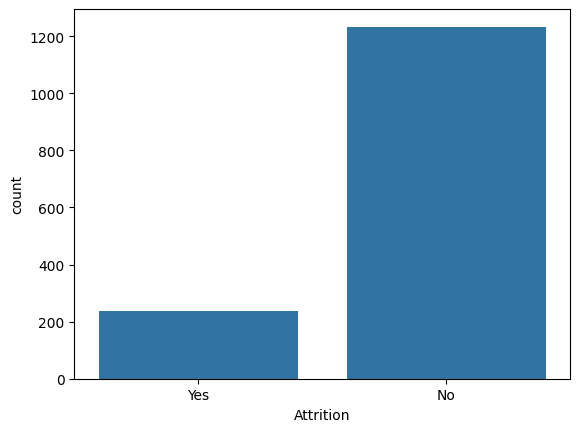

In [672]:
sns.countplot(x='Attrition', data=df)

In [673]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [674]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

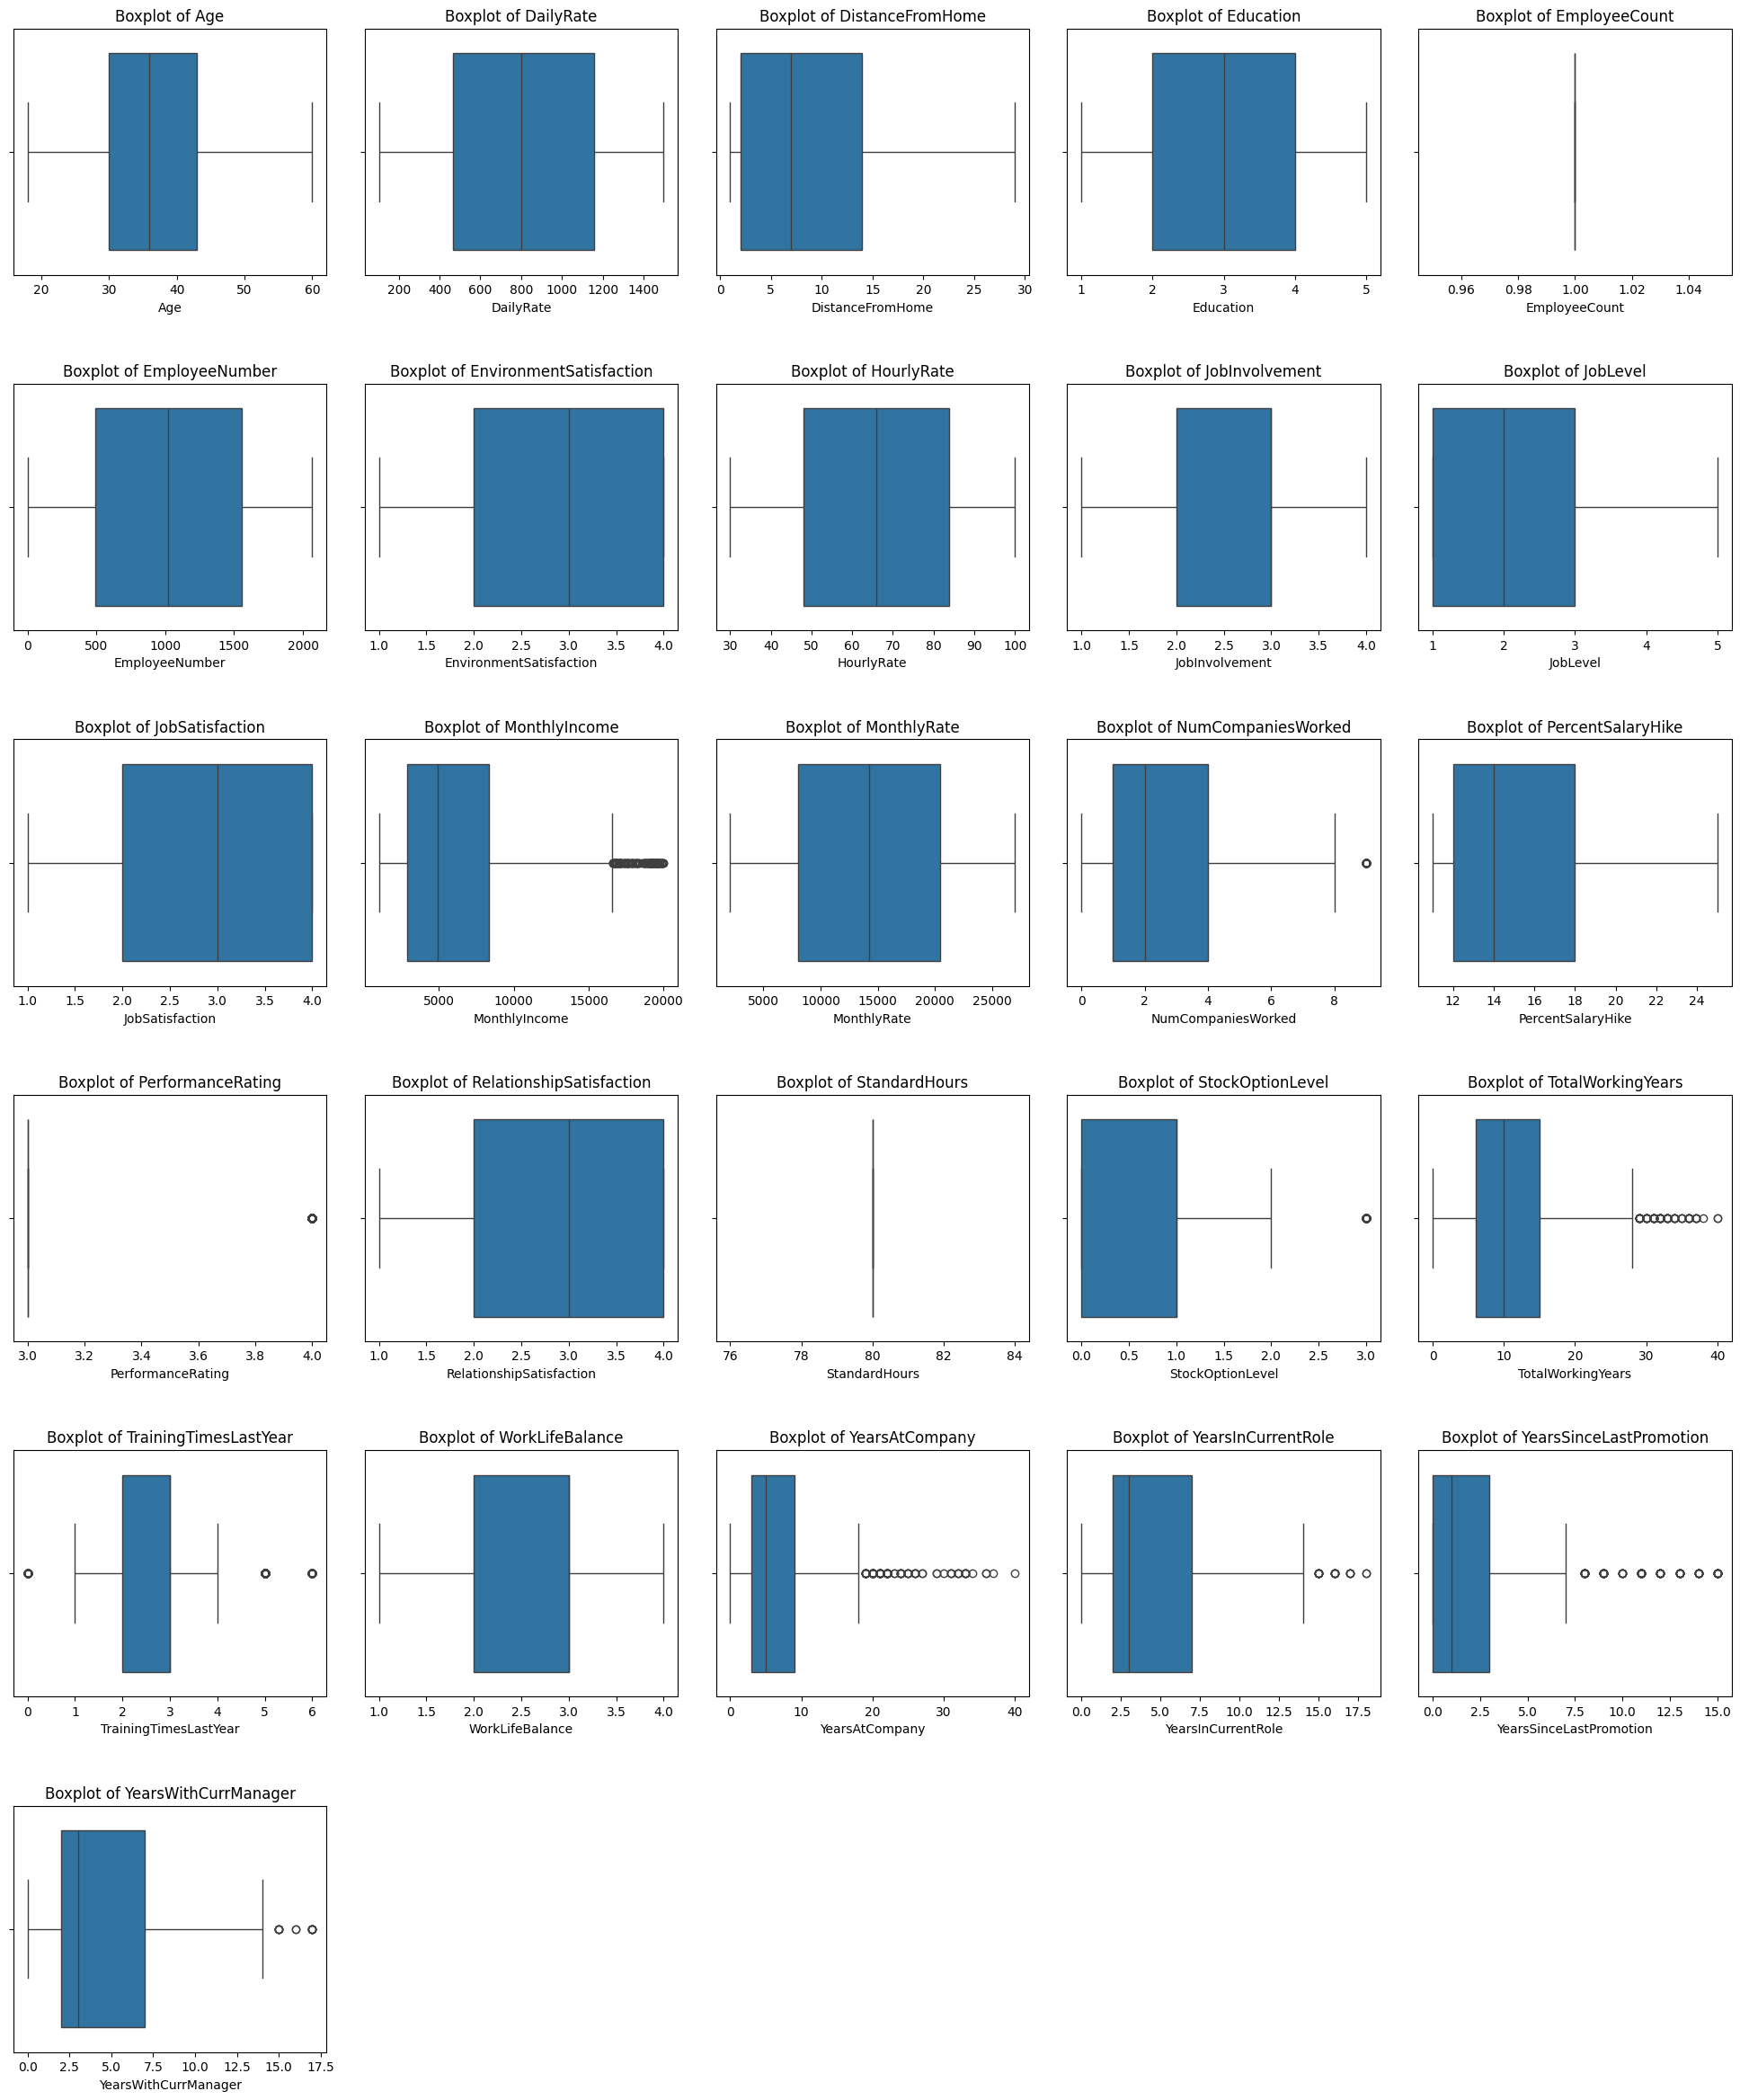

In [675]:
numeric_cols = df.select_dtypes(np.number).columns
numeric_cols_count = len(numeric_cols)
ncols=5
nrows = (numeric_cols_count + ncols - 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 4), squeeze=False)
plot_index =  0 
for col in numeric_cols:
    r=plot_index//ncols
    c=plot_index%ncols 
    sns.boxplot(x=df[col],ax=axs[r][c])
    axs[r][c].set_title(f'Boxplot of {col}')
    plot_index += 1

    #to hide the empty plot
for i in range(plot_index, nrows * ncols):
    r = i // ncols
    c = i % ncols
    axs[r][c].axis('off')

plt.tight_layout(pad=3.0, w_pad=2.0, h_pad=4.0)
plt.show()

In [676]:
df['YearsWithCurrManager'].unique()

array([ 5,  7,  0,  2,  6,  8,  3, 11, 17,  1,  4, 12,  9, 10, 15, 13, 16,
       14])

In [677]:
df['YearsSinceLastPromotion'].unique()

array([ 0,  1,  3,  2,  7,  4,  8,  6,  5, 15,  9, 13, 12, 10, 11, 14])

In [678]:
df['YearsInCurrentRole'].unique()

array([ 4,  7,  0,  2,  5,  9,  8,  3,  6, 13,  1, 15, 14, 16, 11, 10, 12,
       18, 17])

In [679]:
df['YearsAtCompany'].unique()

array([ 6, 10,  0,  8,  2,  7,  1,  9,  5,  4, 25,  3, 12, 14, 22, 15, 27,
       21, 17, 11, 13, 37, 16, 20, 40, 24, 33, 19, 36, 18, 29, 31, 32, 34,
       26, 30, 23])

In [680]:
df['TotalWorkingYears'].unique()

array([ 8, 10,  7,  6, 12,  1, 17,  5,  3, 31, 13,  0, 26, 24, 22,  9, 19,
        2, 23, 14, 15,  4, 29, 28, 21, 25, 20, 11, 16, 37, 38, 30, 40, 18,
       36, 34, 32, 33, 35, 27])

In [681]:
df['TrainingTimesLastYear'].unique()

array([0, 3, 2, 5, 1, 4, 6])

In [682]:
df[df['StockOptionLevel']== 3].shape[0]

85

In [683]:
df['StockOptionLevel'].unique()

array([0, 1, 3, 2])

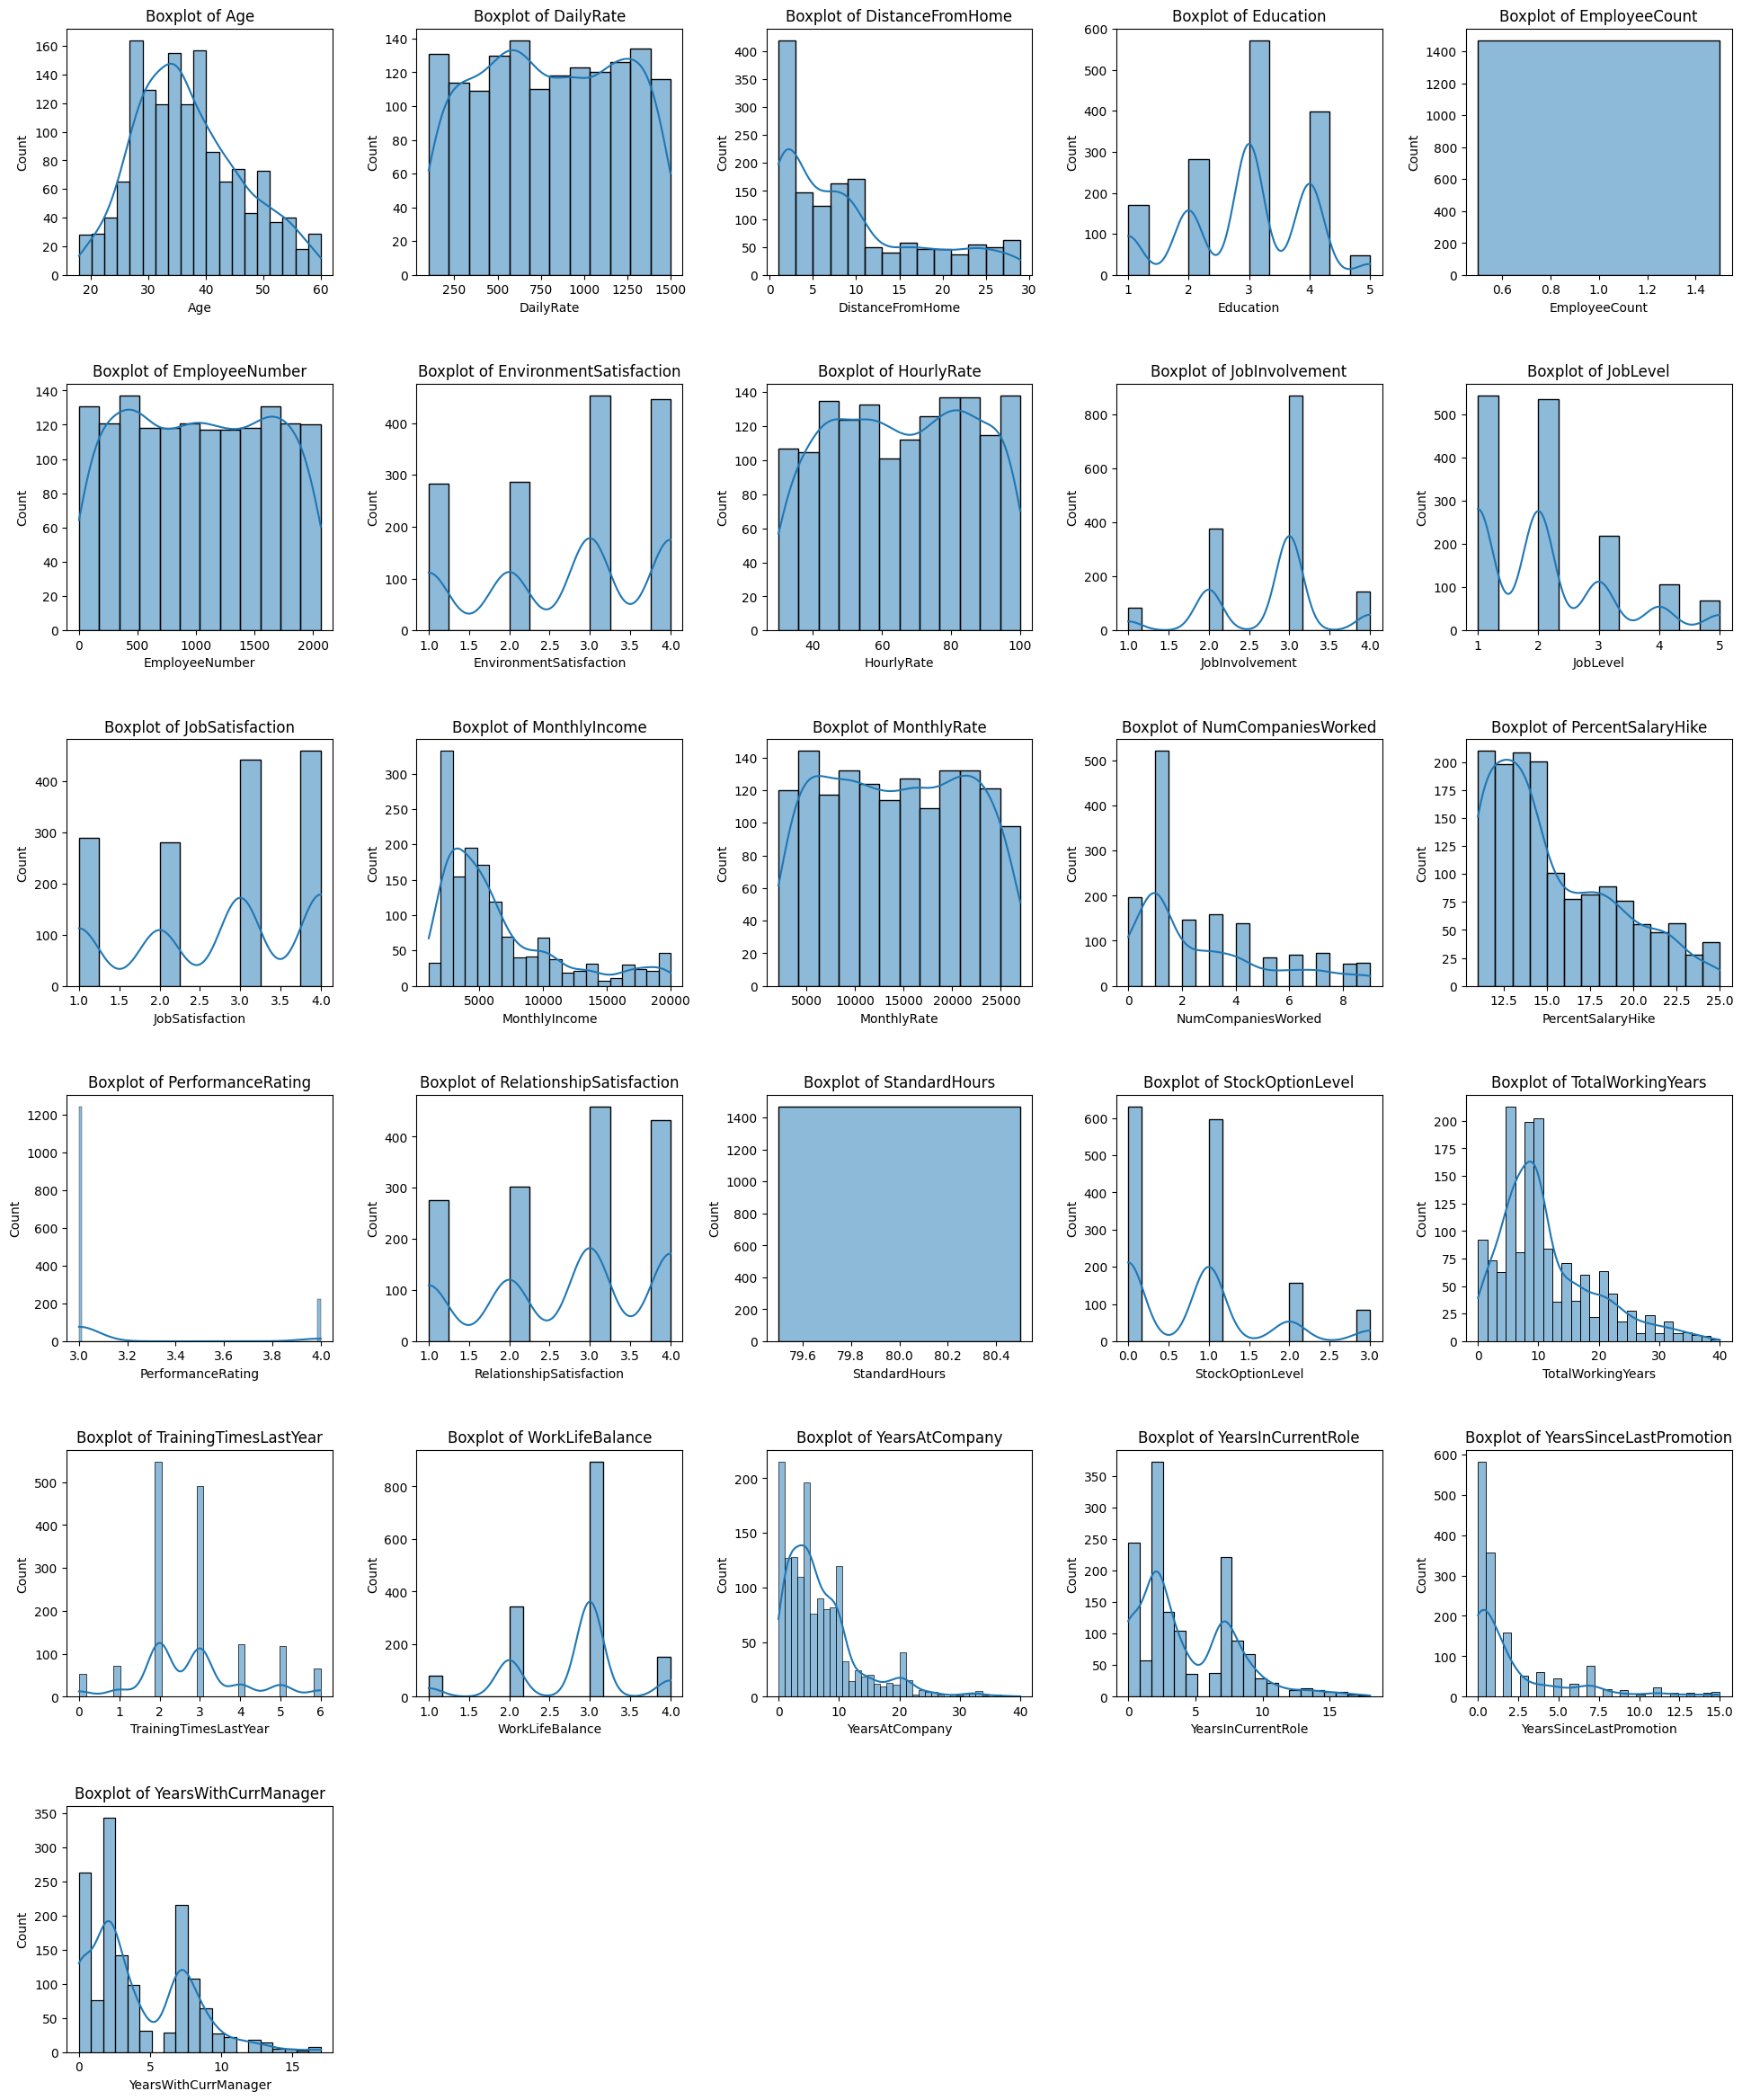

In [684]:
numeric_cols_countnumeric_cols = df.select_dtypes(np.number).columns
numeric_cols_count = len(numeric_cols)
ncols=5
nrows = (numeric_cols_count + ncols - 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(20, nrows * 4), squeeze=False)
plot_index =  0 
for col in numeric_cols:
    r=plot_index//ncols
    c=plot_index%ncols 
    sns.histplot(data=df[col],ax=axs[r][c],kde=True)
    axs[r][c].set_title(f'Boxplot of {col}')
    plot_index += 1

    #to hide the empty plot
for i in range(plot_index, nrows * ncols):
    r = i // ncols
    c = i % ncols
    axs[r][c].axis('off')

plt.tight_layout(pad=3.0, w_pad=2.0, h_pad=4.0)
plt.show()

In [685]:
df['DistanceFromHome'].unique()

array([ 1,  8,  2,  3, 24, 23, 27, 16, 15, 26, 19, 21,  5, 11,  9,  7,  6,
       10,  4, 25, 12, 18, 29, 22, 14, 20, 28, 17, 13])

In [686]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [687]:
df['BusinessTravel'].unique()

array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], dtype=object)

In [688]:
df['Department'].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [689]:
df['EducationField'].unique()

array(['Life Sciences', 'Other', 'Medical', 'Marketing',
       'Technical Degree', 'Human Resources'], dtype=object)

In [690]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [691]:
df['JobRole'].unique()

array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
       'Manufacturing Director', 'Healthcare Representative', 'Manager',
       'Sales Representative', 'Research Director', 'Human Resources'],
      dtype=object)

In [692]:
df['MaritalStatus'].unique()

array(['Single', 'Married', 'Divorced'], dtype=object)

In [693]:
df['Over18'].unique()

array(['Y'], dtype=object)

In [694]:
df.drop('Over18',axis=1, inplace=True)

In [695]:
df['OverTime'].unique()

array(['Yes', 'No'], dtype=object)

In [696]:
le=LabelEncoder()
df['Attrition']=le.fit_transform(df['Attrition'])

In [697]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [698]:
trans_num = ['DistanceFromHome','MonthlyIncome','PercentSalaryHike',
                                                'TotalWorkingYears','YearsAtCompany','YearsSinceLastPromotion','YearsWithCurrManager']
nums = df.select_dtypes(np.number).columns
nums = nums.drop('Attrition', errors='ignore')
scale_cols = [c for c in nums if c not in trans_num]

transformer=ColumnTransformer(transformers=[
    ('num',PowerTransformer(method='yeo-johnson'),trans_num),
    ('sc',StandardScaler(), scale_cols),
    ('cat',OneHotEncoder(sparse_output=False,drop='first'),['Gender','OverTime','EducationField','BusinessTravel','Department','MaritalStatus','JobRole']),
],remainder='passthrough')


# Logistic Regression

In [699]:
pipe = Pipeline([
    ('pre', transformer),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])
pipe.fit(X_train, y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('sc', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [700]:
y_pred_train_pipeline = pipe.predict(X_train)
y_pred_test_pipeline = pipe.predict(X_test)

y_pred_probability= pipe.predict_proba(X_test)[:,1]

In [701]:
print("--- Accuracy Scores ---")
train_accuracy = accuracy_score(y_train, y_pred_train_pipeline)
test_accuracy = accuracy_score(y_test, y_pred_test_pipeline)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

--- Accuracy Scores ---
Training Accuracy: 0.7883
Test Accuracy: 0.7687



In [702]:
print("--- Classification Report (Test Set) ---")
# This report shows Precision, Recall, and F1-score for each class
target_names = ['No Attrition', 'Attrition']
print(classification_report(y_test, y_pred_test_pipeline, target_names=target_names))

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

No Attrition       0.93      0.79      0.85       247
   Attrition       0.38      0.68      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294



In [703]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_probability)
average_precision = average_precision_score(y_test, y_pred_probability)
print(f"Average Precision (AUPRC): {average_precision:.4f}\n")

Average Precision (AUPRC): 0.5560



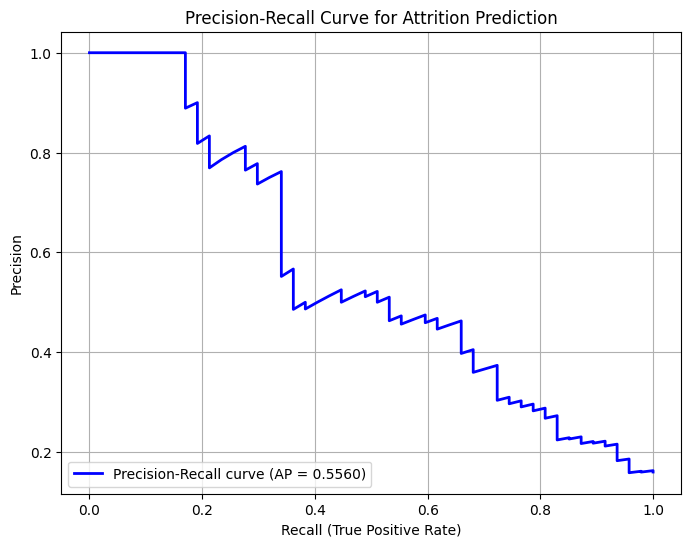

In [704]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, 
        label=f'Precision-Recall curve (AP = {average_precision:.4f})')

# Set labels and title
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Attrition Prediction')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

Optimal Threshold: 0.5639


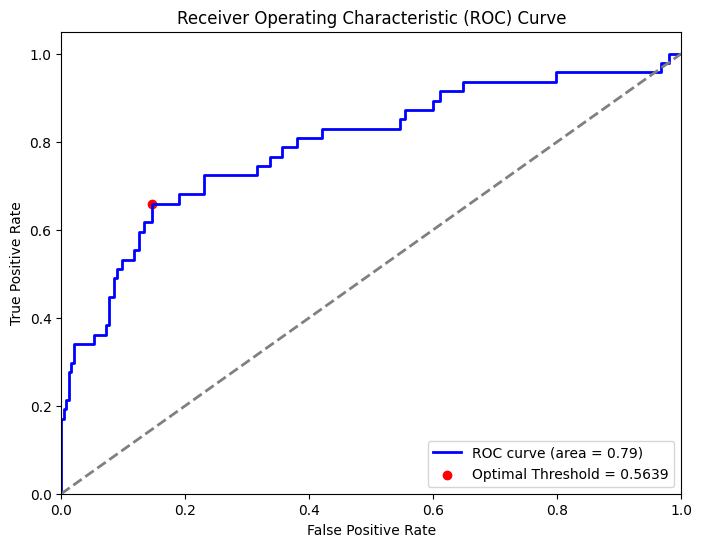

In [744]:
# Compute the false positive rate (fpr), true positive rate (tpr), and thresholds for different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probability)

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

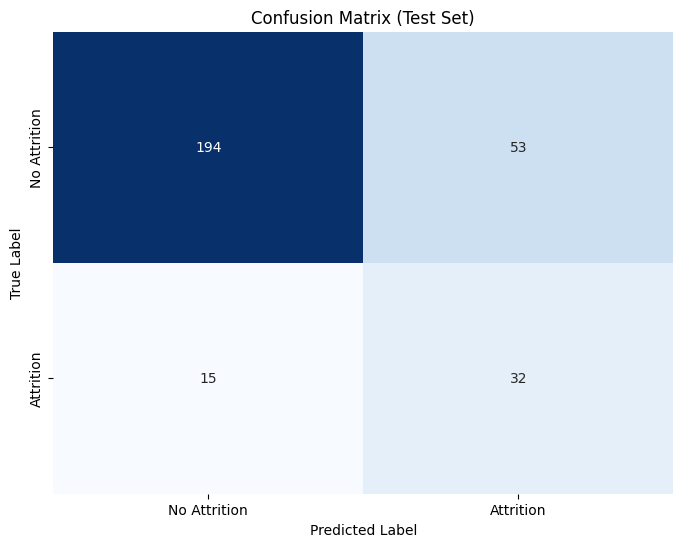

In [706]:
## 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test_pipeline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# KNN

In [735]:
knn_pipe = Pipeline([
    ('pre', transformer),
    ('clf', KNeighborsClassifier(n_neighbors=5,weights='distance',metric='minkowski', p=1,algorithm='auto'))
])
knn_pipe.fit(X_train, y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('sc', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [736]:
y_pred_train_pipeline_knn = knn_pipe.predict(X_train)

y_pred_test_pipeline_knn = knn_pipe.predict(X_test)

y_pred_probability_knn= knn_pipe.predict_proba(X_test)[:,1]

In [737]:
print("--- Accuracy Scores ---")
train_accuracy = accuracy_score(y_train, y_pred_train_pipeline_knn)
test_accuracy = accuracy_score(y_test, y_pred_test_pipeline_knn)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

--- Accuracy Scores ---
Training Accuracy: 1.0000
Test Accuracy: 0.8435



In [738]:
print("--- Classification Report (Test Set) ---")
# This report shows Precision, Recall, and F1-score for each class
target_names = ['No Attrition', 'Attrition']
print(classification_report(y_test, y_pred_test_pipeline_knn, target_names=target_names))

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

No Attrition       0.86      0.98      0.91       247
   Attrition       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294



In [739]:
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_pred_probability_knn)
average_precision = average_precision_score(y_test, y_pred_probability_knn)
print(f"Average Precision (AUPRC): {average_precision:.4f}\n")

Average Precision (AUPRC): 0.3084



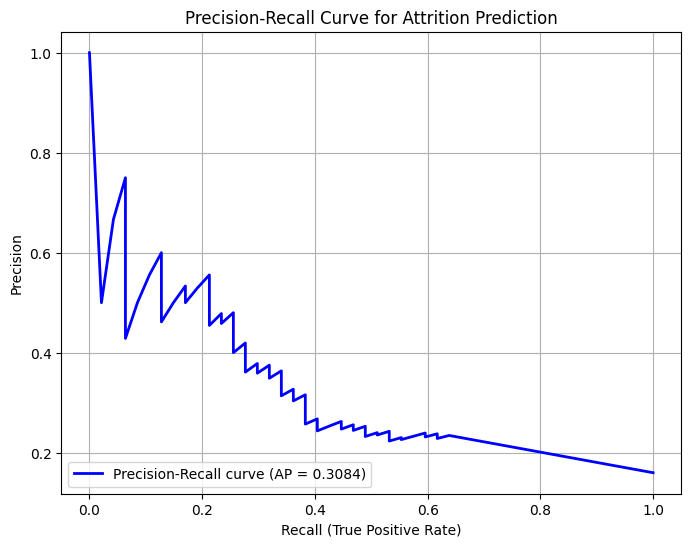

In [740]:
plt.figure(figsize=(8, 6))
plt.plot(recall_knn, precision_knn, color='blue', lw=2, 
        label=f'Precision-Recall curve (AP = {average_precision:.4f})')

# Set labels and title
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Attrition Prediction')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

Optimal Threshold: 0.1702


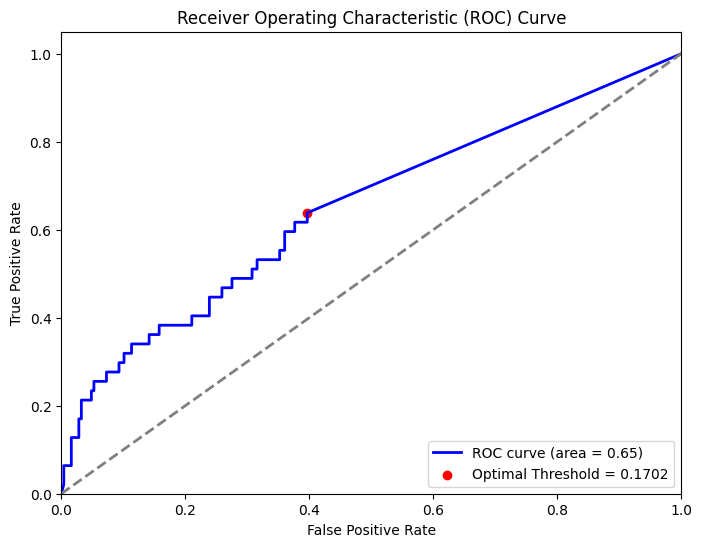

In [745]:
# Compute the false positive rate (fpr), true positive rate (tpr), and thresholds for different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probability_knn)

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Naive Bayes

In [751]:
nb_pipe = Pipeline([
    ('pre', transformer),
    ('clf', GaussianNB())
    ])
nb_pipe.fit(X_train, y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('sc', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [752]:
y_pred_train_pipeline_nb = nb_pipe.predict(X_train)
y_pred_test_pipeline_nb = nb_pipe.predict(X_test)
y_pred_probability_nb= nb_pipe.predict_proba(X_test)[:,1]

In [754]:
print("--- Accuracy Scores ---")
train_accuracy = accuracy_score(y_train, y_pred_train_pipeline_nb)
test_accuracy = accuracy_score(y_test, y_pred_test_pipeline_nb)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

--- Accuracy Scores ---
Training Accuracy: 0.7058
Test Accuracy: 0.6939

